Moment‐matching w: [-0.6104318   0.7064707   0.33139008  0.13584061]
MMD‐matching w: [-0.6543822   0.6671039   0.3356931   0.11860193]


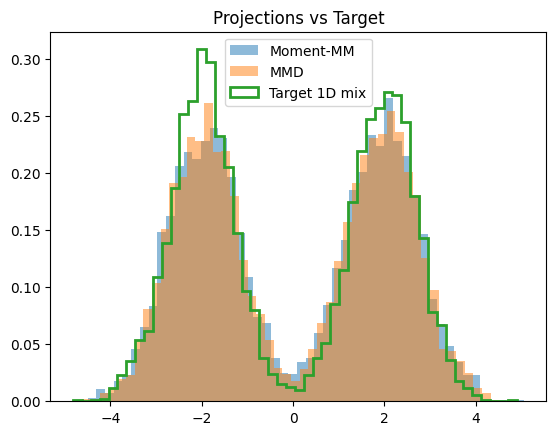

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- 1) Generate mixture of 4 Gaussians in 4D ---
key = jax.random.PRNGKey(42)
N   = 5000
D   = 4
K   = 4

# mixture weights (sum to 1) and random means in R^4
weights4 = jnp.array([0.25, 0.25, 0.25, 0.25])
means4 = jnp.array([
    [ 3.0,  0.0,  0.0,  0.0],
    [-3.0,  0.0,  0.0,  0.0],
    [ 0.0,  3.0,  0.0,  0.0],
    [ 0.0, -3.0,  0.0,  0.0],
])
cov_scale4 = 0.8

# Sample component indices
key, subkey = jax.random.split(key)
u = jax.random.uniform(subkey, shape=(N,))
inds = jnp.searchsorted(jnp.cumsum(weights4), u)

# Draw noise and assemble samples
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N, D)) * cov_scale4
samples4d = means4[inds] + eps  # shape (N,4)

# --- 2) Target 1D mixture of 2 Gaussians ---
weights2 = jnp.array([0.5, 0.5])
means2   = jnp.array([-2.0, 2.0])
var2     = 0.5

key, subkey = jax.random.split(key)
u2   = jax.random.uniform(subkey, shape=(N,))
inds2 = jnp.searchsorted(jnp.cumsum(weights2), u2)

key, subkey = jax.random.split(key)
eps2 = jax.random.normal(subkey, shape=(N,)) * jnp.sqrt(var2)
target1d = means2[inds2] + eps2  # shape (N,)

# Precompute target moments
mu_t  = jnp.mean(target1d)
var_t = jnp.var(target1d)

# Utility: project samples along unit vector w
def project(samples, v):
    w = v / jnp.linalg.norm(v)
    return samples @ w

# --- 3a) Moment matching: optimize v in R^4 so that proj stats match ---
def mm_loss(v):
    y = project(samples4d, v)
    m = jnp.mean(y)
    vvar = jnp.var(y)
    return (m - mu_t)**2 + (vvar - var_t)**2

# Initialize v randomly and run simple GD
v_mm = jax.random.normal(key, shape=(D,))
lr = 0.1
for i in range(500):
    grads = jax.grad(mm_loss)(v_mm)
    v_mm  = v_mm - lr * grads
w_mm = v_mm / jnp.linalg.norm(v_mm)
print("Moment‐matching w:", w_mm)

# --- 3b) MMD matching: RBF kernel MMD loss ---
def rbf_kernel(x, y, sigma=1.0):
    sq = jnp.sum((x[:,None] - y[None,:])**2, axis=-1)
    return jnp.exp(-sq / (2*sigma**2))

def mmd_loss(v):
    y = project(samples4d, v)[:,None]
    t = target1d[:,None]
    Kxx = rbf_kernel(y, y)
    Kyy = rbf_kernel(t, t)
    Kxy = rbf_kernel(y, t)
    return jnp.mean(Kxx) + jnp.mean(Kyy) - 2*jnp.mean(Kxy)

v_mmd = jax.random.normal(key, shape=(D,))
lr2 = 0.05
for i in range(800):
    g2 = jax.grad(mmd_loss)(v_mmd)
    v_mmd = v_mmd - lr2 * g2
w_mmd = v_mmd / jnp.linalg.norm(v_mmd)
print("MMD‐matching w:", w_mmd)

# Optional: compare histograms of the two projections
y_mm  = project(samples4d, w_mm)
y_mmd = project(samples4d, w_mmd)

plt.hist(y_mm,  bins=50, density=True, alpha=0.5, label='Moment‐MM')
plt.hist(y_mmd, bins=50, density=True, alpha=0.5, label='MMD')
plt.hist(target1d, bins=50, density=True,
         histtype='step', linewidth=2, label='Target 1D mix')
plt.legend(); plt.title("Projections vs Target"); plt.show()